# 📝 Exercise M5.01

In the previous notebook, we showed how a tree with 1 level depth works. The
aim of this exercise is to repeat part of the previous experiment for a tree
with 2 levels depth to show how such parameter affects the feature space
partitioning.

We first load the penguins dataset and split it into a training and a testing
sets:

In [1]:
import pandas as pd

penguins = pd.read_csv("../datasets/penguins_classification.csv")
culmen_columns = ["Culmen Length (mm)", "Culmen Depth (mm)"]
target_column = "Species"

<div class="admonition note alert alert-info">
<p class="first admonition-title" style="font-weight: bold;">Note</p>
<p class="last">If you want a deeper overview regarding this dataset, you can refer to the
Appendix - Datasets description section at the end of this MOOC.</p>
</div>

In [2]:
from sklearn.model_selection import train_test_split

data, target = penguins[culmen_columns], penguins[target_column]
data_train, data_test, target_train, target_test = train_test_split(
    data, target, random_state=0
)

Create a decision tree classifier with a maximum depth of 2 levels and fit the
training data.

In [4]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(max_depth=2)
tree.fit(data_train, target_train)

,criterion,'gini'
,splitter,'best'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


Now plot the data and the decision boundary of the trained classifier to see
the effect of increasing the depth of the tree.

Hint: Use the class `DecisionBoundaryDisplay` from the module
`sklearn.inspection` as shown in previous course notebooks.

<div class="admonition warning alert alert-danger">
<p class="first admonition-title" style="font-weight: bold;">Warning</p>
<p class="last">At this time, it is not possible to use <tt class="docutils literal"><span class="pre">response_method="predict_proba"</span></tt> for
multiclass problems on a single plot. This is a planned feature for a future
version of scikit-learn. In the mean time, you can use
<tt class="docutils literal"><span class="pre">response_method="predict"</span></tt> instead.</p>
</div>

<Axes: xlabel='Culmen Length (mm)', ylabel='Culmen Depth (mm)'>

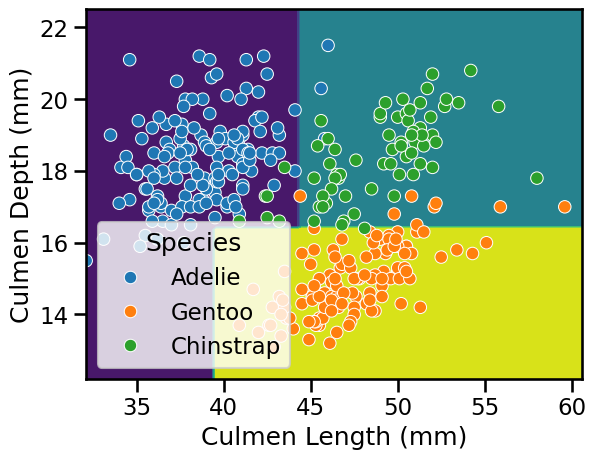

In [14]:
from sklearn.inspection import DecisionBoundaryDisplay
import seaborn as sns

dbd = DecisionBoundaryDisplay.from_estimator(
    tree,
    data_train,
    response_method="predict"
)

sns.scatterplot(
    data=penguins,
    x=culmen_columns[0],
    y=culmen_columns[1],
    hue=target_column
)

Did we make use of the feature "Culmen Length"? Plot the tree using the
function `sklearn.tree.plot_tree` to find out!

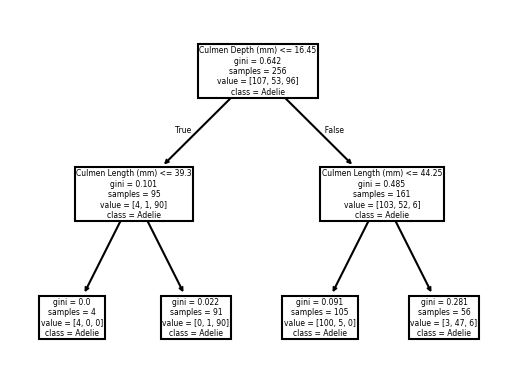

In [24]:
from sklearn.tree import plot_tree

_ = plot_tree(
    tree,
    feature_names=culmen_columns,
    class_names=target_train
)

Indeed, Culmen Length was used this time when having a max depth of 2

Compute the accuracy of the decision tree on the testing data.

In [28]:
tree.score(data_test, target_test)

0.9651162790697675